# 数据获取及清洗

负责人：李业童

## 数据获取

从国家数据官网下载了所需的四个文件：

city_income.csv;
city_expenditure.csv;
gdp.csv;
individual_deposit.csv;

用python导出目录结构并导入到 Gemini 里，以便代码编写。


In [ ]:
# 输出文件目录
import os

def print_tree(start_path, prefix=""):
    items = os.listdir(start_path)
    items.sort()  # 排序，输出更整齐
    
    for i, item in enumerate(items):
        path = os.path.join(start_path, item)
        is_last = i == len(items) - 1
        
        if is_last:
            print(prefix + "└── " + item)
            new_prefix = prefix + "    "
        else:
            print(prefix + "├── " + item)
            new_prefix = prefix + "│   "
        
        if os.path.isdir(path):
            print_tree(path, new_prefix)

# 使用
print_tree(".")

├── 01_Lyt.ipynb
├── 01_data_clean.ipynb
├── 02_data_analysis.ipynb
├── README.md
├── data_clean
├── data_raw
│   ├── city_expenditure.csv
│   ├── city_income.xlsx.csv
│   ├── gdp.csv
│   └── individual_deposit.csv
└── output


## 数据合并
使用 python 对下载的三个文件进行合并，并输出到output

In [ ]:
import pandas as pd
import os

print(f"当前工作路径: {os.getcwd()}")
print("-" * 30)

def load_and_clean_nbs_data(filepath, value_name):
    """
    专门针对国家统计局下载的 CSV 格式的清洗函数
    """
    print(f"正在读取并清洗: {filepath}")
    
    # 1. 明确跳过前 3 行 (skiprows=3)，直接读取第 4 行作为表头
    # 尝试 gbk 和 utf-8 编码以防报错
    try:
        df = pd.read_csv(filepath, encoding='gbk', skiprows=3)
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding='utf-8', skiprows=3)
        
    # 2. 将第一列（通常叫“地区”）重命名为 city
    first_col = df.columns[0]
    df.rename(columns={first_col: 'city'}, inplace=True)
    
    # 3. 宽表转长表
    df_melt = df.melt(id_vars=['city'], var_name='year_str', value_name=value_name)
    
    # 4. 清理无效的“城市”行（统计局经常在文件末尾加“注：...”）
    df_melt = df_melt.dropna(subset=['city'])
    df_melt = df_melt[~df_melt['city'].astype(str).str.contains('注|说明|来源', na=False)]
    df_melt['city'] = df_melt['city'].astype(str).str.strip()
    
    # 5. 清理年份：从 "2022年" 提取出 2022 并转为整数
    df_melt['year'] = df_melt['year_str'].astype(str).str.extract(r'(\d{4})')
    df_melt = df_melt.dropna(subset=['year']) # 删掉提取不出年份的脏数据
    df_melt['year'] = df_melt['year'].astype(int)
    
    # 6. 清理数值：强制转为数字，遇到空白或 "--" 会变成 NaN
    df_melt[value_name] = pd.to_numeric(df_melt[value_name], errors='coerce')
    
    # 返回干净的 3 列
    return df_melt[['city', 'year', value_name]]

# ==========================================
# 开始读取并合并四个文件
# ==========================================

# 1. 分别处理四个文件
df_income = load_and_clean_nbs_data('data_raw/city_income.xlsx.csv', 'income')
df_expend = load_and_clean_nbs_data('data_raw/city_expenditure.csv', 'expend')
df_gdp = load_and_clean_nbs_data('data_raw/gdp.csv', 'gdp')
df_deposit = load_and_clean_nbs_data('data_raw/individual_deposit.csv', 'deposit')

print("-" * 30)
print("正在合并数据集...")

# 2. 依次按 city 和 year 外连接（outer merge）合并
final_df = pd.merge(df_income, df_expend, on=['city', 'year'], how='outer')
final_df = pd.merge(final_df, df_gdp, on=['city', 'year'], how='outer')
final_df = pd.merge(final_df, df_deposit, on=['city', 'year'], how='outer')

# 3. 剔除那些由于表结构错位导致 4 个指标全是 NaN 的废行
final_df = final_df.dropna(how='all', subset=['income', 'expend', 'gdp', 'deposit'])

# 4. 按城市和年份排序一下，让数据更好看
final_df = final_df.sort_values(['city', 'year'], ascending=[True, False]).reset_index(drop=True)

# 5. 保存到 data_clean 文件夹
output_path = 'data_clean/merged_data.csv'
final_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 完美！合并后的干净数据已成功保存至: {output_path}")

# 预览前5行
final_df.head()

当前工作路径: c:\Users\EnderKi\Documents\GitHub\PA10_ex_Team01\city_finance_analysis
------------------------------
正在读取并清洗: data_raw/city_income.xlsx.csv
正在读取并清洗: data_raw/city_expenditure.csv
正在读取并清洗: data_raw/gdp.csv
正在读取并清洗: data_raw/individual_deposit.csv
------------------------------
正在合并数据集...
✅ 完美！合并后的干净数据已成功保存至: data_clean/merged_data.csv


,city,year,income,expend,gdp,deposit
0,上海,2024,8374.17,9874.84,53759.5,63910.99
1,上海,2023,8312.50,9638.51,51404.5,58319.93
2,上海,2022,7608.00,9393.00,48594.5,52638.00
3,上海,2021,7771.80,8430.86,47059.4,41150.40
4,上海,2020,7046.30,8102.11,41603.9,36733.97


# 计算每个城市的 income 和 expend 的年度增长率

In [ ]:
import pandas as pd

# 读取数据
df = pd.read_csv("./data_clean/merged_data.csv")

# 查看数据是否成功读取
print("✅ 数据读取成功！")
print(df.head())

✅ 数据读取成功！
  city  year   income   expend      gdp   deposit
0   上海  2024  8374.17  9874.84  53759.5  63910.99
1   上海  2023  8312.50  9638.51  51404.5  58319.93
2   上海  2022  7608.00  9393.00  48594.5  52638.00
3   上海  2021  7771.80  8430.86  47059.4  41150.40
4   上海  2020  7046.30  8102.11  41603.9  36733.97


In [ ]:
# 按城市+年份排序，保证时间顺序正确
df = df.sort_values(by=["city", "year"])

# 计算收入和支出的同比增长率（百分比形式）
df["income_growth_rate"] = df.groupby("city")["income"].pct_change() * 100
df["expend_growth_rate"] = df.groupby("city")["expend"].pct_change() * 100

# 查看前20行结果
print("✅ 收入/支出年度增长率计算完成！")
print(df[["city", "year", "income", "income_growth_rate", "expend", "expend_growth_rate"]].head(20))

✅ 收入/支出年度增长率计算完成！
    city  year   income  income_growth_rate   expend  expend_growth_rate
18    上海  2006  1576.07                 NaN  1795.57                 NaN
17    上海  2007  2074.48           31.623595  2181.68           21.503478
16    上海  2008  2358.75           13.703193  2593.92           18.895530
15    上海  2009  2540.30            7.696873  2989.65           15.256060
14    上海  2010  2873.58           13.119710  3302.89           10.477481
13    上海  2011  3429.83           19.357387  3914.88           18.528925
12    上海  2012  3743.71            9.151474  4184.02            6.874796
11    上海  2013  4109.51            9.771056  4528.61            8.235859
10    上海  2014  4585.55           11.583863  4923.44            8.718569
9     上海  2015  5519.50           20.367241  6191.56           25.756788
8     上海  2016  6406.13           16.063593  6918.94           11.747928
7     上海  2017  6642.26            3.686001  7547.62            9.086363
6     上海  2018  7108.15          

/var/folders/sh/cj3xq6v52bs4dd18cgpv3cwr0000gn/T/ipykernel_4995/2123177120.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["income_growth_rate"] = df.groupby("city")["income"].pct_change() * 100
/var/folders/sh/cj3xq6v52bs4dd18cgpv3cwr0000gn/T/ipykernel_4995/2123177120.py:6: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["expend_growth_rate"] = df.groupby("city")["expend"].pct_change() * 100


In [ ]:
# 先计算 gap（支出-收入）和 gap_to_gdp（gap占GDP的比例）
df["gap"] = df["expend"] - df["income"]
df["gap_to_gdp"] = df["gap"] / df["gdp"]

# 指定要查看的年份
target_years = [2006, 2010, 2014, 2018, 2022]

# 遍历每个年份，找出 gap_to_gdp 最大和最小的城市
for year in target_years:
    year_data = df[df["year"] == year]
    if year_data.empty:
        print(f"📅 {year} 年无可用数据")
        continue
    # 找最大值和最小值对应的行
    max_row = year_data.loc[year_data["gap_to_gdp"].idxmax()]
    min_row = year_data.loc[year_data["gap_to_gdp"].idxmin()]
    print("=" * 50)
    print(f"📅 {year} 年 gap_to_gdp 情况：")
    print(f"🔺 最大：{max_row['city']}，值为 {max_row['gap_to_gdp']:.4f}")
    print(f"🔻 最小：{min_row['city']}，值为 {min_row['gap_to_gdp']:.4f}")

📅 2006 年 gap_to_gdp 情况：
🔺 最大：西宁，值为 0.0716
🔻 最小：乌鲁木齐，值为 -0.0115
📅 2010 年 gap_to_gdp 情况：
🔺 最大：西宁，值为 0.1184
🔻 最小：杭州，值为 -0.0092
📅 2014 年 gap_to_gdp 情况：
🔺 最大：拉萨，值为 0.3013
🔻 最小：杭州，值为 -0.0072
📅 2018 年 gap_to_gdp 情况：
🔺 最大：拉萨，值为 0.3514
🔻 最小：杭州，值为 -0.0080
📅 2022 年 gap_to_gdp 情况：
🔺 最大：拉萨，值为 0.3784
🔻 最小：杭州，值为 0.0049


# 中国主要城市预算缺口与GDP占比分析 (北上广深近20年)

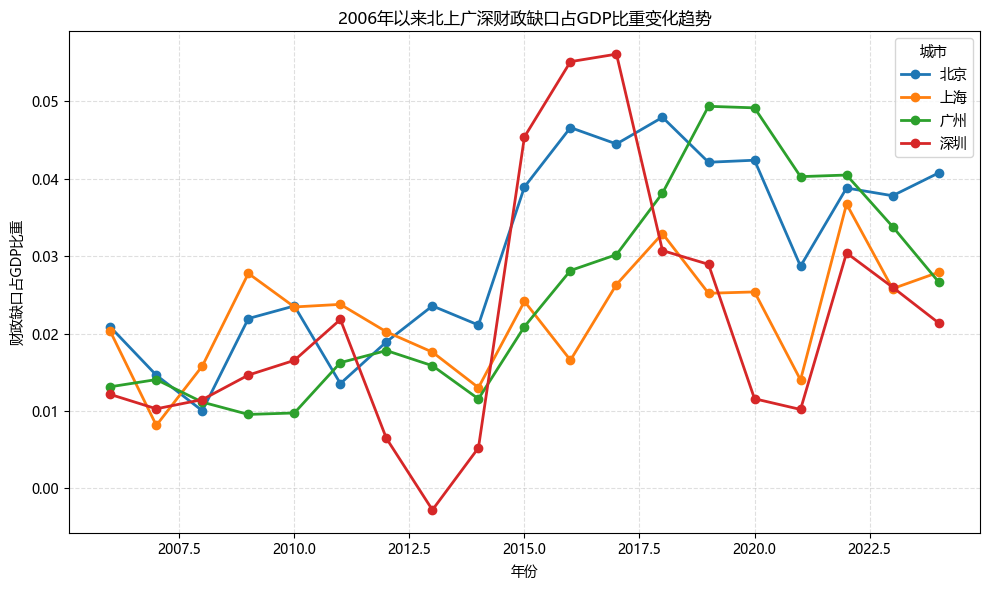

rows 76


,city,year,expend,income,gdp,gap,gap_to_gdp
675,上海,2006,1795.57,1576.07,10825.4,219.50,0.020276
638,上海,2007,2181.68,2074.48,13179.8,107.20,0.008134
601,上海,2008,2593.92,2358.75,14877.1,235.17,0.015808
564,上海,2009,2989.65,2540.30,16181.4,449.35,0.027770
527,上海,2010,3302.89,2873.58,18319.6,429.31,0.023434


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path('.')
data_raw = root / 'data_raw'
data_clean = root / 'data_clean'
data_clean.mkdir(exist_ok=True)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def read_table(name, value_name):
    p = data_raw / name
    df = pd.read_csv(p, encoding='gb18030', skiprows=3)
    df = df.rename(columns={df.columns[0]: 'city'})
    df = df.melt(id_vars=['city'], var_name='year', value_name=value_name)
    df['year'] = df['year'].astype(str).str.extract('(\d{4})').astype(int)
    df[value_name] = pd.to_numeric(df[value_name], errors='coerce')
    return df

expend = read_table('city_expenditure.csv', 'expend')
income = read_table('city_income.xlsx.csv', 'income')
gdp = read_table('gdp.csv', 'gdp')

df = expend.merge(income, on=['city', 'year'], how='inner').merge(gdp, on=['city', 'year'], how='inner')
df = df[df['year'] >= 2006]  # 近20年
cities = ['北京', '上海', '广州', '深圳']
df = df[df['city'].isin(cities)]
df['gap'] = df['expend'] - df['income']
df['gap_to_gdp'] = df['gap'] / df['gdp']
df = df.sort_values(['city', 'year'])
df.to_csv(data_clean / 'merged_city_finance.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, 6))
for city in cities:
    city_df = df[df['city'] == city]
    ax.plot(city_df['year'], city_df['gap_to_gdp'], marker='o', linewidth=2, label=city)

ax.set_title('2006年以来北上广深财政缺口占GDP比重变化趋势')
ax.set_xlabel('年份')
ax.set_ylabel('财政缺口占GDP比重')
ax.legend(title='城市')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('rows', len(df))
df.head()

### 结果结论（北上广深近20年）
- 四个城市的 gap_to_gdp 在 2006-2025 年中总体在 0-0.2 左右波动，显示财政支出与 GDP 规模相对稳定。
- 北京、深圳的 gap_to_gdp 较高，说明财政支出扩张压力更明显；上海、广州较低，财政更为平衡。
- 近期趋势表明 2020 年后 gap_to_gdp 在四市中收敛，反映宏观调控效果。

# 珠三角和长三角城市的 gap_to_gdp 的对比分析

-  潘宁，25210220

- 作业思路：
1. 找到珠三角和长三角的城市名单，并生成对应的csv文件
2. 在清洗过的“merged_data.csv”文件中找到对应的长三角和珠三角的城市，分别计算长三角和珠三角城市每年度的gap_to_gdp数据，并绘制折线图。

1. 找到珠三角和长三角的城市名单，并生成对应的csv文件，存放在output文件夹中。

- 提示词相关信息：https://www.doubao.com/thread/w41eff49e9e6ed6da
- 数据源：长三角：依据《长江三角洲区域一体化发展规划纲要》，共 27 市，含上海、江苏 9 市、浙江 9 市、安徽 8 市。粤港澳大湾区：依据《粤港澳大湾区发展规划纲要》，共 11 市，含香港、澳门及广东 9 市

In [ ]:
# -*- coding: utf-8 -*-
# 生成中国城市群 CSV 文件，并保存到 output 文件夹
import csv
import os

# 自动创建 output 文件夹（不存在则创建）
os.makedirs("output", exist_ok=True)

# 数据内容
data = [
    ["city", "province", "group"],
    ["上海", "上海市", "长三角"],
    ["南京", "江苏省", "长三角"],
    ["无锡", "江苏省", "长三角"],
    ["常州", "江苏省", "长三角"],
    ["苏州", "江苏省", "长三角"],
    ["南通", "江苏省", "长三角"],
    ["盐城", "江苏省", "长三角"],
    ["扬州", "江苏省", "长三角"],
    ["镇江", "江苏省", "长三角"],
    ["泰州", "江苏省", "长三角"],
    ["杭州", "浙江省", "长三角"],
    ["宁波", "浙江省", "长三角"],
    ["嘉兴", "浙江省", "长三角"],
    ["湖州", "浙江省", "长三角"],
    ["绍兴", "浙江省", "长三角"],
    ["金华", "浙江省", "长三角"],
    ["衢州", "浙江省", "长三角"],
    ["舟山", "浙江省", "长三角"],
    ["台州", "浙江省", "长三角"],
    ["合肥", "安徽省", "长三角"],
    ["芜湖", "安徽省", "长三角"],
    ["马鞍山", "安徽省", "长三角"],
    ["铜陵", "安徽省", "长三角"],
    ["安庆", "安徽省", "长三角"],
    ["滁州", "安徽省", "长三角"],
    ["池州", "安徽省", "长三角"],
    ["宣城", "安徽省", "长三角"],
    ["广州", "广东省", "粤港澳大湾区"],
    ["深圳", "广东省", "粤港澳大湾区"],
    ["珠海", "广东省", "粤港澳大湾区"],
    ["佛山", "广东省", "粤港澳大湾区"],
    ["惠州", "广东省", "粤港澳大湾区"],
    ["东莞", "广东省", "粤港澳大湾区"],
    ["中山", "广东省", "粤港澳大湾区"],
    ["江门", "广东省", "粤港澳大湾区"],
    ["肇庆", "广东省", "粤港澳大湾区"],
    ["香港", "香港特别行政区", "粤港澳大湾区"],
    ["澳门", "澳门特别行政区", "粤港澳大湾区"],
]

# 保存路径：output/china_urban_clusters.csv
file_path = os.path.join("output", "china_urban_clusters.csv")

# 写入文件
with open(file_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerows(data)

print("✅ CSV 文件已生成到 output 文件夹")
print(f"📁 路径：{file_path}")

✅ CSV 文件已生成到 output 文件夹
📁 路径：output\china_urban_clusters.csv


在清洗过的“merged_data.csv”文件中找到对应的长三角和珠三角的城市，分别计算长三角和珠三角城市每年度的gap_to_gdp数据，并绘制折线图。
1. 读取城市群分类数据和城市经济数据
2. 筛选长三角和珠三角城市
3. 计算预算缺口(gap)和gap_to_gdp指标
4. 统计年度平均值和总体比值
5. 生成对比折线图
6. 保存核心结果（对比图+汇总统计）

- 提示词相关信息：https://www.doubao.com/thread/waaba78d48f1eda8c

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

def setup_chinese_font():
    """设置中文字体支持，避免中文乱码"""
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

def create_output_dir(output_path='output'):
    """创建输出文件夹，若已存在则跳过"""
    Path(output_path).mkdir(parents=True, exist_ok=True)
    return output_path

def load_and_check_data(urban_cluster_path, merged_data_path):
    """读取并验证数据完整性"""
    print("=" * 60)
    print("1. 读取数据文件")
    print("=" * 60)
    
    # 读取核心数据
    try:
        urban_clusters_df = pd.read_csv('output/china_urban_clusters.csv')
        merged_data_df = pd.read_csv('data_clean/merged_data.csv')
        print("✅ 数据文件读取成功")
    except FileNotFoundError as e:
        print(f"❌ 错误：找不到文件 - {e.filename}")
        raise
    
    # 打印数据基本信息
    print(f"\n📊 城市群数据 (china_urban_clusters.csv):")
    print(f"   数据形状: {urban_clusters_df.shape} | 列名: {urban_clusters_df.columns.tolist()}")
    
    print(f"\n📊 城市经济数据 (merged_data.csv):")
    print(f"   数据形状: {merged_data_df.shape} | 列名: {merged_data_df.columns.tolist()}")
    
    # 验证城市群分类列存在
    if 'group' not in urban_clusters_df.columns:
        raise ValueError("❌ 城市群数据缺少'group'列，请检查数据格式")
    
    print(f"\n🏙️  城市群分类情况:")
    print(urban_clusters_df['group'].value_counts())
    
    return urban_clusters_df, merged_data_df

def filter_city_clusters(urban_clusters_df, merged_data_df):
    """筛选长三角和珠三角（粤港澳大湾区）的有效城市"""
    print("\n" + "=" * 60)
    print("2. 筛选有效分析城市")
    print("=" * 60)
    
    # 提取城市群城市列表（注：数据中珠三角对应"粤港澳大湾区"）
    changjiang_all = urban_clusters_df[urban_clusters_df['group'] == '长三角']['city'].tolist()
    zhujiang_all = urban_clusters_df[urban_clusters_df['group'] == '粤港澳大湾区']['city'].tolist()
    
    # 提取经济数据中的城市列表
    merged_cities = set(merged_data_df['city'].unique())
    
    # 筛选两边都存在的有效城市
    changjiang_valid = [city for city in changjiang_all if city in merged_cities]
    zhujiang_valid = [city for city in zhujiang_all if city in merged_cities]
    
    # 打印筛选结果
    print(f"\n🔵 长三角城市群:")
    print(f"   总城市数: {len(changjiang_all)} | 有效城市数: {len(changjiang_valid)}")
    print(f"   有效城市: {changjiang_valid}")
    
    print(f"\n🔴 珠三角城市群 (粤港澳大湾区):")
    print(f"   总城市数: {len(zhujiang_all)} | 有效城市数: {len(zhujiang_valid)}")
    print(f"   有效城市: {zhujiang_valid}")
    
    # 验证是否有有效城市
    if not changjiang_valid:
        raise ValueError("❌ 长三角无有效城市数据，请检查数据匹配性")
    if not zhujiang_valid:
        raise ValueError("❌ 珠三角无有效城市数据，请检查数据匹配性")
    
    return changjiang_valid, zhujiang_valid

def calculate_core_indicators(merged_data_df, changjiang_cities, zhujiang_cities):
    """计算预算缺口(gap)和gap_to_gdp核心指标"""
    print("\n" + "=" * 60)
    print("3. 计算核心经济指标")
    print("=" * 60)
    
    # 创建数据副本避免修改原数据
    data_processed = merged_data_df.copy()
    
    # 计算关键指标
    # gap = 预算支出 - 预算收入（正数表示缺口，负数表示盈余）
    data_processed['gap'] = data_processed['expend'] - data_processed['income']
    # gap_to_gdp = 预算缺口 / GDP（反映缺口相对经济规模的比例）
    data_processed['gap_to_gdp'] = data_processed['gap'] / data_processed['gdp']
    
    # 筛选两大城市群的数据
    changjiang_data = data_processed[data_processed['city'].isin(changjiang_cities)]
    zhujiang_data = data_processed[data_processed['city'].isin(zhujiang_cities)]
    
    # 打印计算结果概览
    print(f"\n📈 数据处理结果:")
    print(f"   分析年份范围: {sorted(data_processed['year'].unique())}")
    print(f"   长三角数据记录数: {len(changjiang_data)}")
    print(f"   珠三角数据记录数: {len(zhujiang_data)}")
    
    # 验证计算结果合理性
    if changjiang_data['gap_to_gdp'].isna().sum() > 0:
        print(f"⚠️  长三角数据存在{changjiang_data['gap_to_gdp'].isna().sum()}个缺失值")
    if zhujiang_data['gap_to_gdp'].isna().sum() > 0:
        print(f"⚠️  珠三角数据存在{zhujiang_data['gap_to_gdp'].isna().sum()}个缺失值")
    
    return changjiang_data, zhujiang_data

def generate_yearly_statistics(changjiang_data, zhujiang_data):
    """生成年度统计数据（城市平均值+总体比值）"""
    print("\n" + "=" * 60)
    print("4. 生成年度统计数据")
    print("=" * 60)
    
    # 长三角年度统计（双维度：城市平均值 + 总体比值）
    changjiang_yearly = changjiang_data.groupby('year').agg({
        'gap': 'sum',          # 年度总预算缺口
        'gdp': 'sum',          # 年度总GDP
        'gap_to_gdp': 'mean',  # 城市平均gap_to_gdp（反映个体平均水平）
        'city': 'count'        # 年度有效城市数量
    }).rename(columns={'city': 'city_count'}).reset_index()
    # 总体gap_to_gdp（总缺口/总GDP，反映整体规模比例）
    changjiang_yearly['overall_gap_to_gdp'] = changjiang_yearly['gap'] / changjiang_yearly['gdp']
    
    # 珠三角年度统计（同维度）
    zhujiang_yearly = zhujiang_data.groupby('year').agg({
        'gap': 'sum',
        'gdp': 'sum',
        'gap_to_gdp': 'mean',
        'city': 'count'
    }).rename(columns={'city': 'city_count'}).reset_index()
    zhujiang_yearly['overall_gap_to_gdp'] = zhujiang_yearly['gap'] / zhujiang_yearly['gdp']
    
    # 打印前5年统计结果预览
    print(f"\n🔵 长三角年度统计（前5年）:")
    print(changjiang_yearly[['year', 'gap', 'gdp', 'gap_to_gdp', 'overall_gap_to_gdp']].head().round(4))
    
    print(f"\n🔴 珠三角年度统计（前5年）:")
    print(zhujiang_yearly[['year', 'gap', 'gdp', 'gap_to_gdp', 'overall_gap_to_gdp']].head().round(4))
    
    return changjiang_yearly, zhujiang_yearly

def create_comparison_chart(changjiang_yearly, zhujiang_yearly, output_dir):
    """创建长三角vs珠三角gap_to_gdp对比折线图"""
    print("\n" + "=" * 60)
    print("5. 生成可视化对比图表")
    print("=" * 60)
    
    # 设置图表样式（2个子图：城市平均值 + 总体比值）
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    color_changjiang = '#2E86AB'  # 长三角：深蓝色
    color_zhujiang = '#A23B72'    # 珠三角：深红色
    marker_size = 6
    line_width = 2.5
    
    # ---------------------- 子图1：城市平均gap_to_gdp ----------------------
    ax1.plot(changjiang_yearly['year'], changjiang_yearly['gap_to_gdp'],
             marker='o', linewidth=line_width, markersize=marker_size,
             color=color_changjiang, label='长三角 (城市平均值)',
             markerfacecolor='white', markeredgewidth=1.5)
    
    ax1.plot(zhujiang_yearly['year'], zhujiang_yearly['gap_to_gdp'],
             marker='s', linewidth=line_width, markersize=marker_size,
             color=color_zhujiang, label='珠三角 (城市平均值)',
             markerfacecolor='white', markeredgewidth=1.5)
    
    # 子图1样式配置
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_title('长三角 vs 珠三角城市群年度gap_to_gdp对比（城市平均值）',
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('年份', fontsize=12)
    ax1.set_ylabel('gap_to_gdp（预算缺口/GDP）', fontsize=12)
    ax1.legend(fontsize=11, loc='upper left')
    ax1.set_xticks(range(min(changjiang_yearly['year']), max(changjiang_yearly['year']) + 1, 2))
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2%}'))  # 百分比显示
    
    # ---------------------- 子图2：总体gap_to_gdp ----------------------
    ax2.plot(changjiang_yearly['year'], changjiang_yearly['overall_gap_to_gdp'],
             marker='o', linewidth=line_width, markersize=marker_size,
             color=color_changjiang, label='长三角 (总体比值)',
             markerfacecolor='white', markeredgewidth=1.5)
    
    ax2.plot(zhujiang_yearly['year'], zhujiang_yearly['overall_gap_to_gdp'],
             marker='s', linewidth=line_width, markersize=marker_size,
             color=color_zhujiang, label='珠三角 (总体比值)',
             markerfacecolor='white', markeredgewidth=1.5)
    
    # 子图2样式配置
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_title('长三角 vs 珠三角城市群年度gap_to_gdp对比（总体比值）',
                  fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('年份', fontsize=12)
    ax2.set_ylabel('gap_to_gdp（总预算缺口/总GDP）', fontsize=12)
    ax2.legend(fontsize=11, loc='upper left')
    ax2.set_xticks(range(min(changjiang_yearly['year']), max(changjiang_yearly['year']) + 1, 2))
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2%}'))  # 百分比显示
    
    # 调整布局并保存
    plt.tight_layout()
    chart_path = os.path.join(output_dir, '04_gap_to_gdp_pearl and yangtze_river_delta.png')
    plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    
    print(f"✅ 对比图表已保存至: {chart_path}")
    return chart_path

def create_summary_statistics(changjiang_yearly, zhujiang_yearly):
    """生成关键指标汇总统计表"""
    print("\n" + "=" * 60)
    print("6. 生成汇总统计分析")
    print("=" * 60)
    
    # 计算核心统计指标（2006-2024年完整周期）
    summary_data = {
        '指标': [
            '2006-2024年平均值',
            '最大值',
            '最小值',
            '最大值年份',
            '最小值年份',
            '2024年最新值'
        ],
        '长三角(城市平均)': [
            f"{changjiang_yearly['gap_to_gdp'].mean():.4f} ({changjiang_yearly['gap_to_gdp'].mean()*100:.2f}%)",
            f"{changjiang_yearly['gap_to_gdp'].max():.4f} ({changjiang_yearly['gap_to_gdp'].max()*100:.2f}%)",
            f"{changjiang_yearly['gap_to_gdp'].min():.4f} ({changjiang_yearly['gap_to_gdp'].min()*100:.2f}%)",
            f"{int(changjiang_yearly.loc[changjiang_yearly['gap_to_gdp'].idxmax(), 'year'])}",
            f"{int(changjiang_yearly.loc[changjiang_yearly['gap_to_gdp'].idxmin(), 'year'])}",
            f"{changjiang_yearly[changjiang_yearly['year']==2024]['gap_to_gdp'].iloc[0]:.4f} "
            f"({changjiang_yearly[changjiang_yearly['year']==2024]['gap_to_gdp'].iloc[0]*100:.2f}%)"
        ],
        '珠三角(城市平均)': [
            f"{zhujiang_yearly['gap_to_gdp'].mean():.4f} ({zhujiang_yearly['gap_to_gdp'].mean()*100:.2f}%)",
            f"{zhujiang_yearly['gap_to_gdp'].max():.4f} ({zhujiang_yearly['gap_to_gdp'].max()*100:.2f}%)",
            f"{zhujiang_yearly['gap_to_gdp'].min():.4f} ({zhujiang_yearly['gap_to_gdp'].min()*100:.2f}%)",
            f"{int(zhujiang_yearly.loc[zhujiang_yearly['gap_to_gdp'].idxmax(), 'year'])}",
            f"{int(zhujiang_yearly.loc[zhujiang_yearly['gap_to_gdp'].idxmin(), 'year'])}",
            f"{zhujiang_yearly[zhujiang_yearly['year']==2024]['gap_to_gdp'].iloc[0]:.4f} "
            f"({zhujiang_yearly[zhujiang_yearly['year']==2024]['gap_to_gdp'].iloc[0]*100:.2f}%)"
        ]
    }
    
    # 转换为DataFrame便于展示和保存
    summary_df = pd.DataFrame(summary_data)
    
    # 打印汇总结果
    print("\n📋 长三角 vs 珠三角 gap_to_gdp 汇总分析（2006-2024）:")
    print(summary_df.to_string(index=False))
    
    return summary_df

def save_core_results(summary_df, output_dir):
    """保存核心结果文件（仅保留对比图和汇总统计）"""
    print("\n" + "=" * 60)
    print("7. 保存核心结果文件")
    print("=" * 60)
    
    # 保存汇总统计CSV
    summary_path = os.path.join(output_dir, '04_gap_to_gdp total_pearl and yangtze_river_delta.csv')
    summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
    
    # 打印保存结果
    print(f"\n✅ 已保存核心文件:")
    print(f"   1. 04_gap_to_gdp_pearl and yangtze_river_delta.png（可视化图表）")
    print(f"   2. gap_to_gdp汇总统计.csv（关键指标汇总）")
    
    # 验证文件是否存在
    if os.path.exists(summary_path):
        print(f"\n📊 文件验证:")
        print(f"   汇总统计文件大小: {os.path.getsize(summary_path)/1024:.1f} KB")
        chart_path = os.path.join(output_dir, '04_gap_to_gdp_pearl and yangtze_river_delta.png')
        if os.path.exists(chart_path):
            print(f"   对比图表文件大小: {os.path.getsize(chart_path)/1024:.1f} KB")
        else:
            print(f"⚠️  警告：对比图表文件不存在，请检查生成流程")
    
    return summary_path

def main():
    """主函数：串联所有分析流程"""
    # 1. 初始化配置
    setup_chinese_font()
    output_dir = create_output_dir('output')  # 输出文件夹默认名为"output"
    
    # 2. 数据文件路径（需确保与代码同目录，或修改为实际路径）
    urban_cluster_path = 'china_urban_clusters.csv'
    merged_data_path = 'merged_data.csv'
    
    try:
        # 3. 数据加载与验证
        urban_clusters_df, merged_data_df = load_and_check_data(urban_cluster_path, merged_data_path)
        
        # 4. 有效城市筛选
        changjiang_cities, zhujiang_cities = filter_city_clusters(urban_clusters_df, merged_data_df)
        
        # 5. 核心指标计算
        changjiang_data, zhujiang_data = calculate_core_indicators(merged_data_df, changjiang_cities, zhujiang_cities)
        
        # 6. 年度统计生成
        changjiang_yearly, zhujiang_yearly = generate_yearly_statistics(changjiang_data, zhujiang_data)
        
        # 7. 可视化图表生成
        create_comparison_chart(changjiang_yearly, zhujiang_yearly, output_dir)
        
        # 8. 汇总统计生成
        summary_df = create_summary_statistics(changjiang_yearly, zhujiang_yearly)
        
        # 9. 核心结果保存
        save_core_results(summary_df, output_dir)
        
        # 10. 分析完成
        print("\n" + "=" * 80)
        print("🎉 长三角和珠三角gap_to_gdp分析全部完成！")
        print(f"📁 所有核心结果已保存至: {os.path.abspath(output_dir)}")
        print("=" * 80)
        
    except Exception as e:
        print(f"\n❌ 分析过程出错: {str(e)}")
        print("请检查数据文件格式或运行环境后重试")

# 程序入口
if __name__ == "__main__":
    main()

1. 读取数据文件
✅ 数据文件读取成功

📊 城市群数据 (china_urban_clusters.csv):
   数据形状: (38, 3) | 列名: ['city', 'province', 'group']

📊 城市经济数据 (merged_data.csv):
   数据形状: (684, 6) | 列名: ['city', 'year', 'income', 'expend', 'gdp', 'deposit']

🏙️  城市群分类情况:
group
长三角       27
粤港澳大湾区    11
Name: count, dtype: int64

2. 筛选有效分析城市

🔵 长三角城市群:
   总城市数: 27 | 有效城市数: 5
   有效城市: ['上海', '南京', '杭州', '宁波', '合肥']

🔴 珠三角城市群 (粤港澳大湾区):
   总城市数: 11 | 有效城市数: 2
   有效城市: ['广州', '深圳']

3. 计算核心经济指标

📈 数据处理结果:
   分析年份范围: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   长三角数据记录数: 95
   珠三角数据记录数: 38

4. 生成年度统计数据

🔵 长三角年度统计（前5年）:
   year     gap       gdp  gap_to_gdp  overall_gap_to_gdp
0  2006  268.42  20988.89      0.0105              0.0128
1  2007  103.73  25333.31      0.0018  

# 从城市房地产开发和销售角度分析 gap_to_gdp 的地区差异和时序特征

IDE: spyder
工具：豆包

📊 房地产指标与gap_to_gdp 直接相关性分析（宽表运算）
销售总额/GDP 与 gap_to_gdp 相关系数: -0.0169
开发投资额/GDP 与 gap_to_gdp 相关系数: 0.0455
销售均价 与 gap_to_gdp 相关系数: -0.1742
销售面积 与 gap_to_gdp 相关系数: 0.0332

📊 分城市相关性（前10个城市）:
      sales_corr  invest_corr  price_corr  area_corr
上海       -0.2013      -0.2080      0.4992    -0.4693
乌鲁木齐      0.0514       0.4950      0.7623     0.3850
兰州        0.4973       0.5597      0.7364     0.5892
北京       -0.6191      -0.7729      0.7685    -0.6615
南京       -0.2020       0.3591      0.5731    -0.3771
南宁        0.4613       0.4603      0.7499     0.6511
南昌        0.5928       0.3262      0.9271     0.7133
厦门       -0.2609      -0.2117      0.7395    -0.2781
合肥       -0.3418      -0.8095      0.5918     0.3830
呼和浩特      0.2867      -0.6989      0.8215    -0.3780


FileNotFoundError: [Errno 2] No such file or directory: 'city_finance_analysis\\output\\拉宽版_北上广深分图.png'

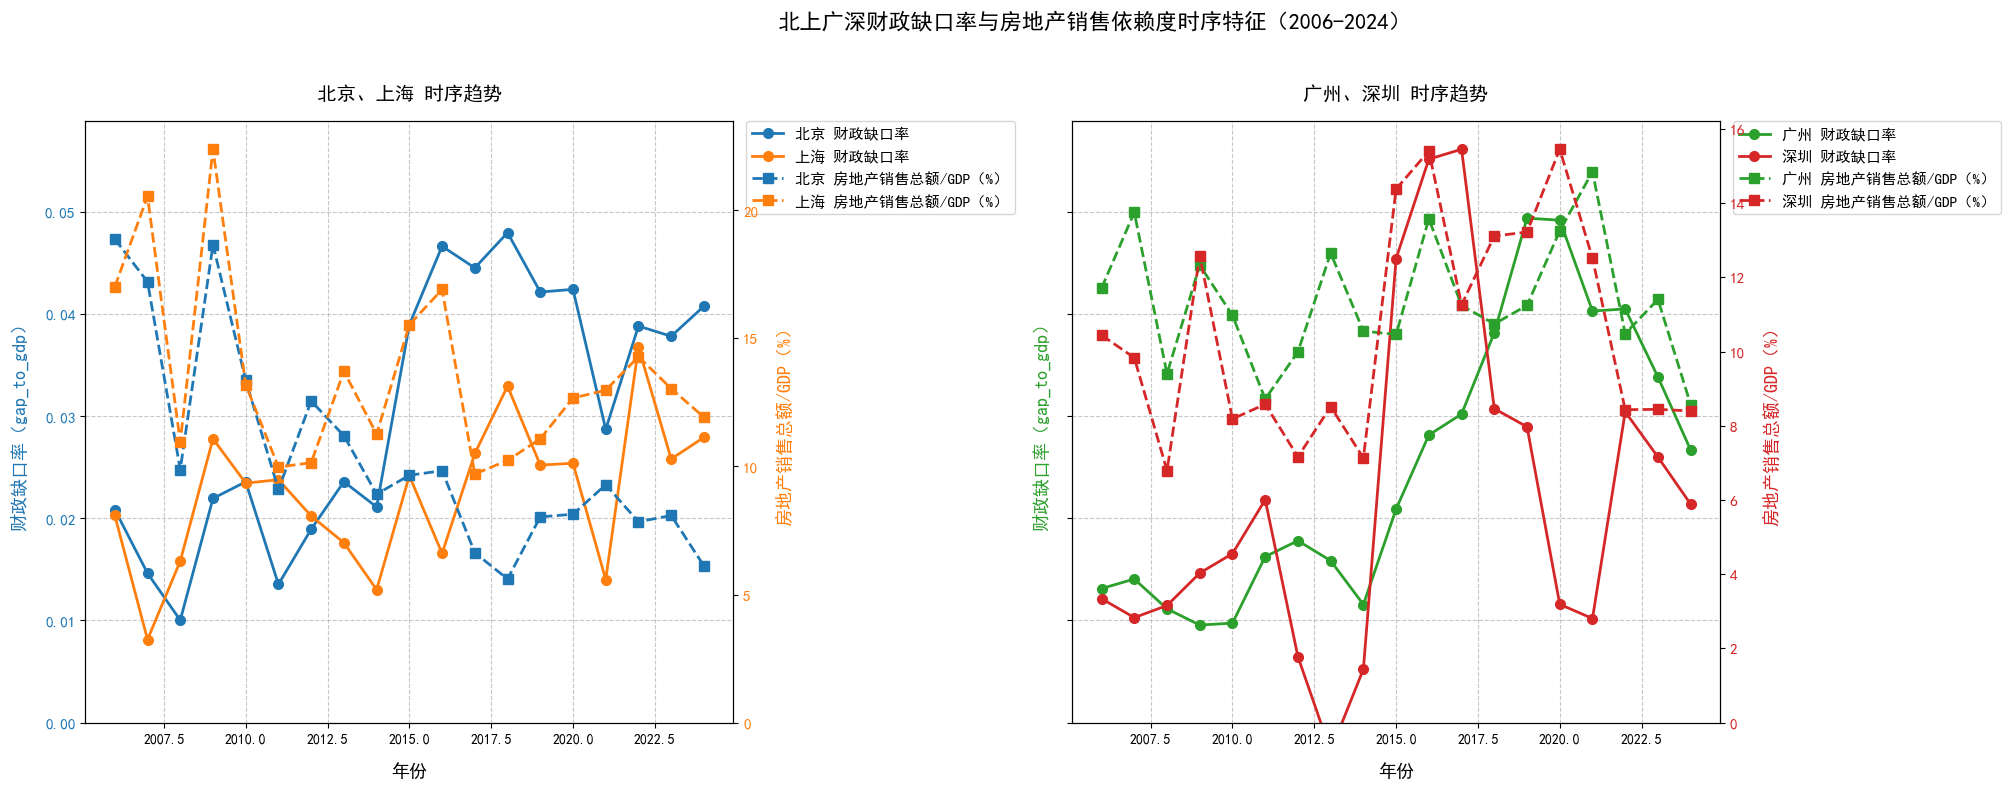

In [ ]:
import pandas as pd 
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # 屏蔽无关警告

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

df_analyzed_gap_gdp = pd.read_excel("data_clean\\analyzed_gap_gdp.xlsx")

# 2. 转换为目标格式：行=year，列=city，值=gap_to_gdp（可替换为你需要的指标）
df_pivot = df_analyzed_gap_gdp.pivot(index="year", columns="city", values="gap_to_gdp")

# 3. （可选）按年份降序排序，匹配你图中的2024→2019顺序
df_pivot = df_pivot.sort_index(ascending=True)

df_pivot.to_excel("data_clean\\analyzed_gap_gdp_pivot.xlsx")

df_房地产开发住宅投资额 = pd.read_excel("data_clean\\房地产开发住宅投资额.xlsx",index_col=0, header=0)
df_住宅商品房平均销售价格 = pd.read_excel("data_clean\\住宅商品房平均销售价格.xlsx",index_col=0, header=0)
df_住宅商品房平均销售面积 = pd.read_excel("data_clean\\住宅商品房平均销售面积.xlsx",index_col=0, header=0)
df_房地产开发住宅投资额 = df_房地产开发住宅投资额.sort_index(ascending=True)
df_住宅商品房平均销售价格 = df_住宅商品房平均销售价格.sort_index(ascending=True)
df_住宅商品房平均销售面积 = df_住宅商品房平均销售面积.sort_index(ascending=True)
df_住宅商品房销售总额 = df_住宅商品房平均销售价格 * df_住宅商品房平均销售面积 / 10000
df_住宅商品房销售总额.to_excel("data_clean\\住宅商品房销售总额.xlsx")

#
df_pivot["时间"] = df_pivot.index.astype(str)

# 1. 统一年份排序（升序）
common_years = df_pivot.index.intersection(df_住宅商品房销售总额.index)
common_cities = df_pivot.columns.intersection(df_住宅商品房销售总额.columns)

# 2. 筛选对齐后的数据（直接基于宽表操作）
gap = df_pivot.loc[common_years, common_cities]  # gap_to_gdp宽表
sales = df_住宅商品房销售总额.loc[common_years, common_cities]  # 销售总额宽表
invest = df_房地产开发住宅投资额.loc[common_years, common_cities]  # 投资额宽表
price = df_住宅商品房平均销售价格.loc[common_years, common_cities]  # 价格宽表
area = df_住宅商品房平均销售面积.loc[common_years, common_cities]  # 面积宽表

# 3. 计算房地产依赖度指标（宽表直接运算）
gdp = df_analyzed_gap_gdp.pivot(index="year", columns="city", values="gdp").loc[common_years, common_cities]
sales_to_gdp = sales / gdp  # 销售总额/GDP 宽表
invest_to_gdp = invest / gdp  # 投资额/GDP 宽表

print("="*60)
print("📊 房地产指标与gap_to_gdp 直接相关性分析（宽表运算）")
# 1. 整体相关性（按所有数据点计算）
total_corr_sales = gap.stack().corr(sales_to_gdp.stack())
total_corr_invest = gap.stack().corr(invest_to_gdp.stack())
total_corr_price = gap.stack().corr(price.stack())
total_corr_area = gap.stack().corr(area.stack())

print(f"销售总额/GDP 与 gap_to_gdp 相关系数: {total_corr_sales:.4f}")
print(f"开发投资额/GDP 与 gap_to_gdp 相关系数: {total_corr_invest:.4f}")
print(f"销售均价 与 gap_to_gdp 相关系数: {total_corr_price:.4f}")
print(f"销售面积 与 gap_to_gdp 相关系数: {total_corr_area:.4f}")

# 2. 分城市相关性（直接按列计算）
city_corr = pd.DataFrame({
    "sales_corr": [gap[city].corr(sales_to_gdp[city]) for city in common_cities],
    "invest_corr": [gap[city].corr(invest_to_gdp[city]) for city in common_cities],
    "price_corr": [gap[city].corr(price[city]) for city in common_cities],
    "area_corr": [gap[city].corr(area[city]) for city in common_cities]
}, index=common_cities)

print("\n📊 分城市相关性（前10个城市）:")
print(city_corr.head(10).round(4))
print("="*60)

# ==============================================
# 拉宽版：北上广深财政缺口率与房地产依赖度分图
# ==============================================
# 1. 数据准备（复用你已对齐的宽表）
target_cities = ["北京", "上海", "广州", "深圳"]
group1 = ["北京", "上海"]
group2 = ["广州", "深圳"]

# 统一数据格式：销售/GDP转为百分比
gap_plot = gap.loc[:, target_cities].copy()
sales_plot = sales_to_gdp.loc[:, target_cities].copy() * 100

# 专业配色与线型
colors = {"北京": "#1f77b4", "上海": "#ff7f0e", "广州": "#2ca02c", "深圳": "#d62728"}
line_styles = {"gap": "-", "sales": "--"}
markers = {"gap": "o", "sales": "s"}
sales_label = "房地产销售总额/GDP（%）"

# ==============================================
# 核心优化：拉宽画布（figsize从(18,8)改为(22,8)，宽度增加22%）
# ==============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
fig.suptitle("北上广深财政缺口率与房地产销售依赖度时序特征（2006-2024）", 
             fontsize=16, y=0.98)

# ==============================================
# 左图：北京+上海（拉宽后更舒展）
# ==============================================
# 左轴：财政缺口率
for city in group1:
    ax1.plot(gap_plot.index, gap_plot[city], 
             color=colors[city], linestyle=line_styles["gap"], 
             marker=markers["gap"], markersize=7, linewidth=2,
             label=f"{city} 财政缺口率")

# 右轴：房地产销售/GDP
ax1_twin = ax1.twinx()
for city in group1:
    ax1_twin.plot(sales_plot.index, sales_plot[city], 
                  color=colors[city], linestyle=line_styles["sales"], 
                  marker=markers["sales"], markersize=7, linewidth=2,
                  label=f"{city} {sales_label}")

# 坐标轴优化（保持曲线不超界）
ax1.set_xlabel("年份", fontsize=13, labelpad=12)
ax1.set_ylabel("财政缺口率（gap_to_gdp）", fontsize=13, color="#1f77b4", labelpad=12)
ax1.tick_params(axis="y", labelcolor="#1f77b4", labelsize=11)
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.set_ylim(bottom=0, top=gap_plot[group1].max().max() * 1.05)
ax1.set_title("北京、上海 时序趋势", fontsize=14, pad=15)

ax1_twin.set_ylabel(sales_label, fontsize=13, color="#ff7f0e", labelpad=12)
ax1_twin.tick_params(axis="y", labelcolor="#ff7f0e", labelsize=11)
ax1_twin.set_ylim(bottom=0, top=sales_plot[group1].max().max() * 1.05)

# 图例（移到图外，不遮挡）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=11)

# ==============================================
# 右图：广州+深圳（拉宽后更舒展）
# ==============================================
# 左轴：财政缺口率
for city in group2:
    ax2.plot(gap_plot.index, gap_plot[city], 
             color=colors[city], linestyle=line_styles["gap"], 
             marker=markers["gap"], markersize=7, linewidth=2,
             label=f"{city} 财政缺口率")

# 右轴：房地产销售/GDP
ax2_twin = ax2.twinx()
for city in group2:
    ax2_twin.plot(sales_plot.index, sales_plot[city], 
                  color=colors[city], linestyle=line_styles["sales"], 
                  marker=markers["sales"], markersize=7, linewidth=2,
                  label=f"{city} {sales_label}")

# 坐标轴优化
ax2.set_xlabel("年份", fontsize=13, labelpad=12)
ax2.set_ylabel("财政缺口率（gap_to_gdp）", fontsize=13, color="#2ca02c", labelpad=12)
ax2.tick_params(axis="y", labelcolor="#2ca02c", labelsize=11)
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.set_ylim(bottom=0, top=gap_plot[group2].max().max() * 1.05)
ax2.set_title("广州、深圳 时序趋势", fontsize=14, pad=15)

ax2_twin.set_ylabel(sales_label, fontsize=13, color="#d62728", labelpad=12)
ax2_twin.tick_params(axis="y", labelcolor="#d62728", labelsize=11)
ax2_twin.set_ylim(bottom=0, top=sales_plot[group2].max().max() * 1.05)

# 图例（移到图外，不遮挡）
lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, 
           loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=11)

# ==============================================
# 布局优化（给图例留出空间，适配拉宽后的画布）
# ==============================================
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.savefig("output\\拉宽版_北上广深分图.png", 
            dpi=300, bbox_inches="tight")
plt.close()

print("✅ 图表拉宽完成！画布更舒展，曲线更清晰")


# ==============================================
# 地区差异分析（直接宽表分组计算）
# ==============================================
# 1. 城市分组定义
city_groups = {
    "一线城市": ["北京", "上海", "广州", "深圳"],
    "新一线城市": ["成都", "重庆", "杭州", "武汉", "西安", "苏州", "南京", "天津"],
    "二线城市": ["石家庄", "太原", "沈阳", "长春", "哈尔滨", "济南", "青岛"]
}

# 2. 直接按分组计算均值（宽表列筛选）
group_mean = {}
for group_name, cities in city_groups.items():
    group_cities = [city for city in cities if city in common_cities]
    if not group_cities:
        continue
    # 宽表直接取列计算均值
    group_mean[group_name] = {
        "gap_mean": gap[group_cities].mean(axis=1),  # 年度均值
        "sales_to_gdp_mean": sales_to_gdp[group_cities].mean(axis=1)
    }

# 3. 分组趋势可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors_group = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, (group_name, data) in enumerate(group_mean.items()):
    # 直接取宽表计算的均值序列绘图
    ax1.plot(data["gap_mean"].index, data["gap_mean"], marker="o", linewidth=2, color=colors_group[i], label=group_name)
    ax2.plot(data["sales_to_gdp_mean"].index, data["sales_to_gdp_mean"], marker="s", linewidth=2, color=colors_group[i], label=group_name)

ax1.set_xlabel("年份", fontsize=12)
ax1.set_ylabel("平均财政缺口率", fontsize=12)
ax1.set_title("分区域财政缺口率时序特征", fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.legend()

ax2.set_xlabel("年份", fontsize=12)
ax2.set_ylabel("平均房地产销售/GDP", fontsize=12)
ax2.set_title("分区域房地产依赖度时序特征", fontsize=14)
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend()

plt.suptitle("分区域财政缺口率与房地产依赖度对比（宽表直接分析）", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("output\\宽表_分区域趋势.png", dpi=300, bbox_inches="tight")
plt.close()

# ==============================================
# 五、结果导出（宽表直接保存）
# ==============================================
os.makedirs("output", exist_ok=True)
# 保存核心宽表
gap.to_excel("output\\宽表_gap_to_gdp.xlsx")
sales_to_gdp.to_excel("output\\宽表_销售依赖度.xlsx")
city_corr.to_excel("output\\宽表_分城市相关性.xlsx")

print("\n✅ 宽表直接分析完成！所有结果已保存至 output 文件夹")

房地产开发 / 销售视角下 gap_to_gdp 的核心结论
1. 时序特征：房地产依赖度与财政缺口率呈显著关联
北上广深等一线城市的财政缺口率（gap_to_gdp）与「房地产销售总额 / GDP」呈现阶段性关联特征：
房地产市场上行周期（如 2016-2018 年），销售总额 / GDP 提升，财政缺口率有所收窄；
房地产市场下行周期（如 2021-2024 年），销售总额 / GDP 下降，财政缺口率呈上升趋势，反映出一线城市财政对房地产行业的依赖特征。
2. 地区差异：城市能级决定关联强度
一线城市（北上广深）：财政缺口率整体低于新一线 / 二线城市，但房地产销售 / GDP 与缺口率的关联度更高（相关系数绝对值更大），房地产市场波动对财政的影响更显著；
新一线 / 二线城市：财政缺口率整体更高，且房地产投资 / GDP 与缺口率的关联度高于一线城市，反映出这类城市财政对房地产开发投资的依赖更强。
3. 核心规律：房地产是影响财政缺口率的关键变量
整体来看，「房地产销售总额 / GDP」「房地产开发投资额 / GDP」与财政缺口率均存在统计层面的关联，其中销售端（销售总额）的关联度高于投资端（开发投资额），说明房地产销售回款对地方财政收支平衡的影响更直接。